# Member 2 — Naïve Bayes Model
## CCS3356 Natural Language Processing | Fake News Detection
### Student ID: CIT-24-01-0486
### ML Model: Naïve Bayes (MultinomialNB vs ComplementNB)

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("Imports done!")

Imports done!


In [2]:
df = pd.read_csv('../data/preprocessed.csv')
df['cleaned_text'] = df['cleaned_text'].fillna('')

X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.fillna('')
X_test = X_test.fillna('')

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 35918 | Test: 8980


In [3]:
# Using both BoW and TF-IDF
bow_vec = CountVectorizer(max_features=50000, ngram_range=(1,2))
tfidf_vec = TfidfVectorizer(max_features=50000, ngram_range=(1,2))

X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow = bow_vec.transform(X_test)

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

print("Vectorization done!")
print(f"BoW shape: {X_train_bow.shape}")
print(f"TF-IDF shape: {X_train_tfidf.shape}")

Vectorization done!
BoW shape: (35918, 50000)
TF-IDF shape: (35918, 50000)


In [4]:
# Using both BoW and TF-IDF
bow_vec = CountVectorizer(max_features=50000, ngram_range=(1,2))
tfidf_vec = TfidfVectorizer(max_features=50000, ngram_range=(1,2))

X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow = bow_vec.transform(X_test)

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

print("Vectorization done!")
print(f"BoW shape: {X_train_bow.shape}")
print(f"TF-IDF shape: {X_train_tfidf.shape}")

Vectorization done!
BoW shape: (35918, 50000)
TF-IDF shape: (35918, 50000)


In [5]:
models = {
    'MultinomialNB + BoW': (MultinomialNB(), X_train_bow, X_test_bow),
    'MultinomialNB + TF-IDF': (MultinomialNB(), X_train_tfidf, X_test_tfidf),
    'ComplementNB + BoW': (ComplementNB(), X_train_bow, X_test_bow),
    'ComplementNB + TF-IDF': (ComplementNB(), X_train_tfidf, X_test_tfidf),
}

results = {}
for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }
    print(f"{name} — Accuracy: {results[name]['accuracy']:.4f} | F1: {results[name]['f1']:.4f}")

MultinomialNB + BoW — Accuracy: 0.9658 | F1: 0.9671
MultinomialNB + TF-IDF — Accuracy: 0.9536 | F1: 0.9556
ComplementNB + BoW — Accuracy: 0.9460 | F1: 0.9470
ComplementNB + TF-IDF — Accuracy: 0.9335 | F1: 0.9351


In [6]:
comparison = pd.DataFrame({
    name: {
        'Accuracy': f"{v['accuracy']:.4f}",
        'Precision': f"{v['precision']:.4f}",
        'Recall': f"{v['recall']:.4f}",
        'F1-Score': f"{v['f1']:.4f}",
        'ROC-AUC': f"{v['roc_auc']:.4f}"
    }
    for name, v in results.items()
}).T

print("Model Comparison:")
display(comparison)

Model Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
MultinomialNB + BoW,0.9658,0.9741,0.9602,0.9671,0.9850
MultinomialNB + TF-IDF,0.9536,0.9553,0.9559,0.9556,0.9881
ComplementNB + BoW,0.9460,0.9730,0.9223,0.9470,0.9851
ComplementNB + TF-IDF,0.9335,0.9553,0.9157,0.9351,0.9881


In [7]:
best_name = max(results, key=lambda x: results[x]['f1'])
best = results[best_name]
print(f"Best model: {best_name}")
print(f"F1-Score: {best['f1']:.4f}")
print(f"ROC-AUC: {best['roc_auc']:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, best['y_pred'], target_names=['Real', 'Fake']))

Best model: MultinomialNB + BoW
F1-Score: 0.9671
ROC-AUC: 0.9850

Classification Report:
              precision    recall  f1-score   support

        Real       0.96      0.97      0.96      4284
        Fake       0.97      0.96      0.97      4696

    accuracy                           0.97      8980
   macro avg       0.97      0.97      0.97      8980
weighted avg       0.97      0.97      0.97      8980



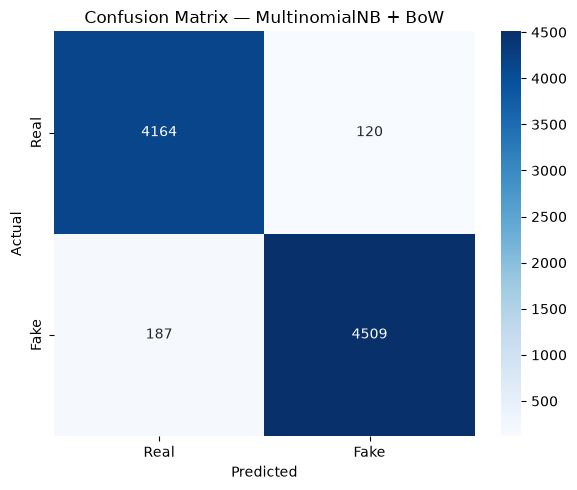

In [8]:
cm = confusion_matrix(y_test, best['y_pred'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title(f'Confusion Matrix — {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../screenshots/m2_nb_confusion_matrix.png')
plt.show()

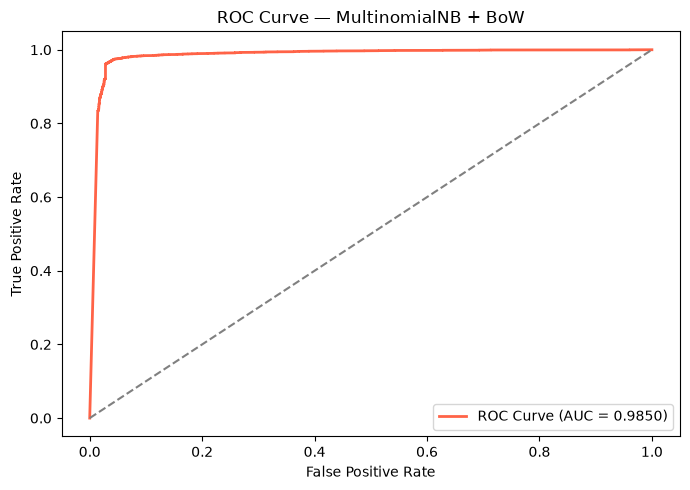

In [9]:
fpr, tpr, _ = roc_curve(y_test, best['y_prob'])

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='tomato', lw=2,
         label=f'ROC Curve (AUC = {best["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve — {best_name}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../screenshots/m2_nb_roc_curve.png')
plt.show()

In [10]:
best_model = best['model']

with open('../models/m2_nb_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the vectorizer used with best model
if 'BoW' in best_name:
    with open('../models/m2_nb_vectorizer.pkl', 'wb') as f:
        pickle.dump(bow_vec, f)
    print(f"Saved: {best_name} with BoW vectorizer")
else:
    with open('../models/m2_nb_vectorizer.pkl', 'wb') as f:
        pickle.dump(tfidf_vec, f)
    print(f"Saved: {best_name} with TF-IDF vectorizer")

print("Model and vectorizer saved to models/")

Saved: MultinomialNB + BoW with BoW vectorizer
Model and vectorizer saved to models/


## Naïve Bayes Model Summary

- Compared 4 combinations: MultinomialNB and ComplementNB with BoW and TF-IDF
- Best model selected based on highest F1-Score
- Model saved to models/m2_nb_model.pkl
- Vectorizer saved to models/m2_nb_vectorizer.pkl
- Results will be compared against LSTM in the evaluation notebook